# NF-Injections

Learn the density of parameters in GWTC-4 data, conditioned on some detection probability (FAR).

### Imports

In [1]:
import os
import h5py
import numpy as np
import pandas as pd
from scipy.special import logit, expit

import matplotlib.pyplot as plt
import corner

import jax
import jax.numpy as jnp
import optax
import equinox as eqx

# FlowJAX (new API)
from flowjax.flows import masked_autoregressive_flow
from flowjax.distributions import Normal

from pathlib import Path

import seaborn as sns
from tqdm import tqdm

import utils as ut

# silence unnecessary warnings about some specific model not being available (shouldn't hurt performance according to ChatGPT)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import os
import socket
print(f"Hostname: {socket.gethostname()}")
print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES')}")
!nvidia-smi

Hostname: usm-cl-nv01.hpc.physik.uni-muenchen.de
CUDA_VISIBLE_DEVICES: 0
Tue Jan 27 19:29:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 NVL                On  |   00000000:07:00.0 Off |                    0 |
| N/A   52C    P0            108W /  400W |   72705MiB /  95830MiB |     43%      Default |
|                                         |                        

In [3]:
jax.devices()

[CudaDevice(id=0)]

In [4]:
# load injection data
def read_data(file: str, gwtc_version: int) -> pd.DataFrame:
    # Load
    raw_injection_data = h5py.File(file, 'r')
    # injections now called events in gwtc4
    if gwtc_version == 3:
        events = raw_injection_data['injections']
        m1_key, m2_key, dist_key, redshift_key = "mass1", "mass2", "distance", "redshift"
    elif gwtc_version == 4:
        events = raw_injection_data["events"]
        m1_key, m2_key, dist_key, redshift_key = "mass1_detector", "mass2_detector", "luminosity_distance", "z"
    print("Data length:", len(events))

    # Read injection parameters
    injectionData = pd.DataFrame()
    injectionData['m1_detector'] = np.array(events[m1_key][()], dtype='float64')
    injectionData['m2_detector'] = np.array(events[m2_key][()], dtype='float64')
    injectionData['luminosity_distance'] = events[dist_key][()]/1000.  # Convert from Mpc to Gpc
    injectionData['cos_inclination'] = np.cos(events['inclination'])
    injectionData['right_ascension'] = events['right_ascension']
    injectionData['declination'] = events['declination']
    injectionData['polarization'] = events['polarization']
    injectionData['redshift'] = events[redshift_key][()]

    # add source-frame quantities
    injectionData["m1_source"] = injectionData['m1_detector'] / (1 + injectionData['redshift'])
    injectionData["m2_source"] = injectionData['m2_detector'] / (1 + injectionData['redshift'])
    
    # Some derived mass parameters
    injectionData['q'] = injectionData.m2_detector/injectionData.m1_detector
    injectionData['eta'] = injectionData.m1_detector*injectionData.m2_detector/(injectionData.m1_detector+injectionData.m2_detector)**2
    injectionData['chirp_mass_detector'] = injectionData.eta**(3./5.)*(injectionData.m1_detector+injectionData.m2_detector)
    injectionData['total_mass_detector'] = (injectionData.m1_detector+injectionData.m2_detector)

    # And some derived spin parameters
    s1x = np.array(events['spin1x'])
    s1y = np.array(events['spin1y'])
    s1z = np.array(events['spin1z'])
    s2x = np.array(events['spin2x'])
    s2y = np.array(events['spin2y'])
    s2z = np.array(events['spin2z'])
    injectionData['s1x'] = s1x
    injectionData['s1y'] = s1y
    injectionData['s1z'] = s1z
    injectionData['s2x'] = s2x
    injectionData['s2y'] = s2y
    injectionData['s2z'] = s2z
    injectionData['a1'] = np.sqrt(s1x**2 + s1y**2 + s1z**2)
    injectionData['a2'] = np.sqrt(s2x**2 + s2y**2 + s2z**2)
    injectionData['cost1'] = s1z/injectionData.a1
    injectionData['cost2'] = s2z/injectionData.a2
    injectionData['Xeff'] = (s1z + injectionData.q*s2z)/(1.+injectionData.q)
    injectionData['Xdiff'] = (s1z - injectionData.q*s2z)/(1.+injectionData.q)
    # injectionData['Xp_gen'] = generalized_Xp(s1x, s1y, s2x,  s2y, injectionData.q)
    
    if gwtc_version == 4:
        #changed in GWTC4
        far_min = np.min([events['%s_far'%search][:] for search in raw_injection_data.attrs['searches']], axis=0)

        """injectionData['p_draw'] = np.exp(raw_injection_data['lnpdraw_mass1_source_mass2_source_redshift_spin1x_spin1y_spin1z_spin2x_spin2y_spin2z'][:])/(1+injectionData['redshift'])**2/ddL_of_z(injectionData['redshift'],injectionData['luminosity_distance'],H0cosmo)
        T = (raw_injection_data.attrs['total_analysis_time'])/(3600.0*24.0*365.25) 
        injectionData['p_draw'] /= T
        
        injectionData['weights'] = events['weights'][()]
        injectionData['p_draw'] /= injectionData['weights'] # ädont think i should do this here"""
        
    injectionData['far_min'] = far_min
    injectionData['detected'] = np.where(far_min < 1, 1, 0)
    print("Number of detected injections:", np.sum(injectionData['detected']))

    return injectionData

### Load File

In [5]:
# fname = Path("/hildafs/home/jgassert/hildafs_phy220048p_symlink/share/GWTC-PESamples/posterior_samples/O4/GWTC-4_bbh_posterior_samples_seed1.h5")
# fname = Path("/project/ls-gruen/users/julius.gassert/data/GWTC-4_bbh_posterior_samples_seed1.h5")
fname = Path("/project/ls-gruen/users/julius.gassert/data/samples-rpo4a_v2_20250503133839UTC-1366933504-23846400.hdf")

f = h5py.File(fname, "r")
f.keys()

<KeysViewHDF5 ['events']>

In [6]:
data_df = read_data(fname, 4)

# sel = data_df["detected"] == True
# data_df = data_df.loc[sel]
data_df

Data length: 1499244
Number of detected injections: 476406


,m1_detector,m2_detector,luminosity_distance,cos_inclination,right_ascension,declination,polarization,redshift,m1_source,m2_source,...,s2y,s2z,a1,a2,cost1,cost2,Xeff,Xdiff,far_min,detected
0,87.680089,56.912638,4.007806,-0.002645,5.002674,-0.254790,0.614705,0.651001,53.107216,34.471587,...,-0.054713,0.140737,0.992925,0.153102,0.222660,0.919241,0.189459,0.078669,inf,0
1,54.408109,49.680587,2.381053,-0.489065,0.409010,-0.917783,0.058546,0.421988,38.261991,34.937406,...,-0.005047,0.015369,0.132586,0.017526,0.575831,0.876912,0.047243,0.032572,inf,0
2,51.668975,20.366343,2.690371,0.910738,5.263240,-0.698737,2.663313,0.467684,35.204419,13.876515,...,0.004414,0.091046,0.357269,0.138341,-0.616144,0.658126,-0.132151,-0.183633,inf,0
3,102.782254,86.531760,3.907749,0.868521,3.848270,-0.599299,0.296581,0.637607,62.763700,52.840380,...,-0.232603,0.452075,0.119832,0.573475,-0.100166,0.788309,0.200118,-0.213152,inf,0
4,40.381354,34.546820,3.611020,0.871280,2.204904,1.053326,2.647054,0.597428,25.278974,21.626521,...,0.046088,0.001241,0.506828,0.103000,0.124223,0.012047,0.034503,0.033359,inf,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499239,42.069507,27.655349,1.836552,-0.788572,5.592748,1.044990,0.352504,0.338223,31.436848,20.665728,...,0.003893,-0.020833,0.975976,0.025391,-0.227340,-0.820504,-0.142137,-0.125610,inf,0
1499240,141.587869,108.244782,9.694232,-0.826559,0.428992,1.191597,0.822922,1.334967,60.638067,46.358168,...,0.389229,-0.186936,0.621683,0.458171,-0.027931,-0.408005,-0.090835,0.071153,inf,0
1499241,101.335786,100.248667,4.904618,0.857559,3.778430,-0.948454,1.955454,0.768044,57.315187,56.700316,...,-0.281385,-0.176928,0.235198,0.408538,0.872972,-0.433076,0.015227,0.191201,inf,0
1499242,4.701713,3.397398,0.335602,-0.448865,0.864340,0.470035,0.662202,0.072109,4.385478,3.168891,...,0.033415,0.671648,0.266395,0.684567,-0.705303,0.981128,0.172668,-0.390815,inf,0


### Prepare the data

FORWARD / INVERSE TRANSFORMS + WHITENING

In [8]:
X_data = ut.Data(
    data_df,
    cols=["m1_detector", "m2_detector", "luminosity_distance",
          "Xeff",],
    handle_inf="clip",  # Clip outliers
)
#
# Targets with inf values - use strategy appropriate for your data
y_df = pd.DataFrame({"far_min": data_df["far_min"].values})
# 
# Option 1: Clip inf to 99.9th percentile of finite values
y_data = ut.Data(y_df, cols=["far_min"], handle_inf="clip", inf_clip_percentile=99.9)
#
# Option 2: Drop rows with inf (will also drop corresponding X rows)
# y_data = Data(y_df, cols=["redshift"], handle_inf="drop")
#
# Option 3: Fill inf with a large value
# y_data = Data(y_df, cols=["redshift"], handle_inf="fill", inf_fill_value=1e6)
#
# Check cleaning info
print("Y data cleaning:", y_data.get_cleaning_info())
#
# Create dataset
dataset = ut.Dataset(X=X_data, y=y_data, 
                  use_whitened_X=True, use_whitened_y=True)

E0127 19:26:06.466421     427 ptx_compiler_helpers.cc:132] *** WARNING *** Invoking ptxas with version 12.6.20, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


Y data cleaning: {'n_inf': 525394, 'n_nan': 0, 'n_total_special': 525394, 'strategy': 'clip', 'col_0_upper_bound': 2607942.0, 'col_0_lower_bound': 0.0}


In [9]:
# check that transform + inverse transform is identity
reverse_transform_data = X_data.inverse_transform(X_data.samples_transformed)
np.allclose(reverse_transform_data, X_data.samples, rtol=1e-6, atol=1e-6) # standard atol is slightly lower, but this is fine

True

In [10]:
# check that transform + whiten + inverse whiten + inverse transform is identity
x_white = X_data.whitened_data
x_rec = X_data.inverse_whiten_data(x_white)
np.allclose(x_rec, X_data.samples, rtol=9.9e-2, atol=1e-3), np.count_nonzero(np.isclose(x_rec, X_data.samples,rtol=1e-4, atol=1e-5))

(True, np.int64(4780043))

In [11]:
# check transformations are good on Dataset class
print("Data Shape", dataset.X_data.get_shape(), "makes", dataset.X_data.get_shape()[0]*dataset.X_data.get_shape()[1], "entries")
X_recovered_dataset, y_recovered_dataset = dataset.to_original_space(dataset.X_data.whitened_data, dataset.y_data.whitened_data)
np.count_nonzero(np.isclose(X_data.data_df.to_numpy(), np.array(X_recovered_dataset),rtol=1e-2, atol=1e-3))

Data Shape (1499244, 6) makes 8995464 entries


np.int64(8995464)

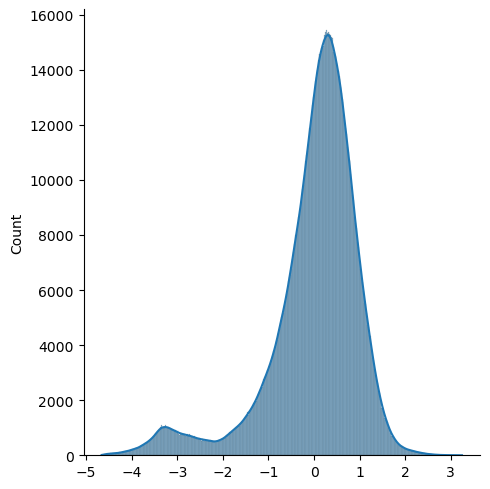

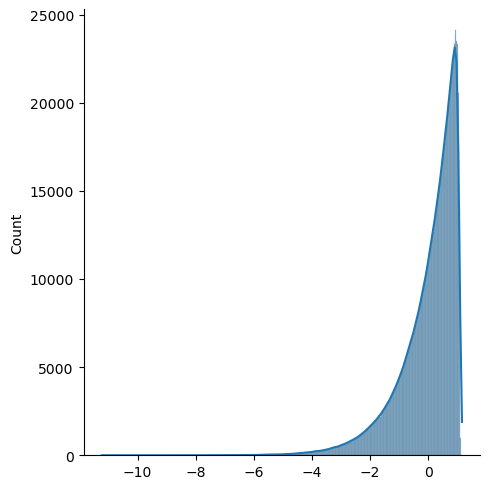

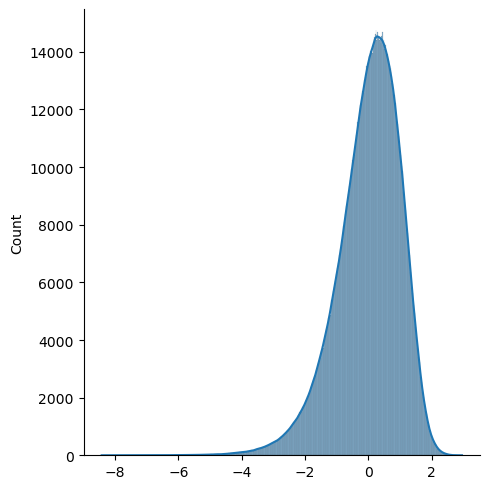

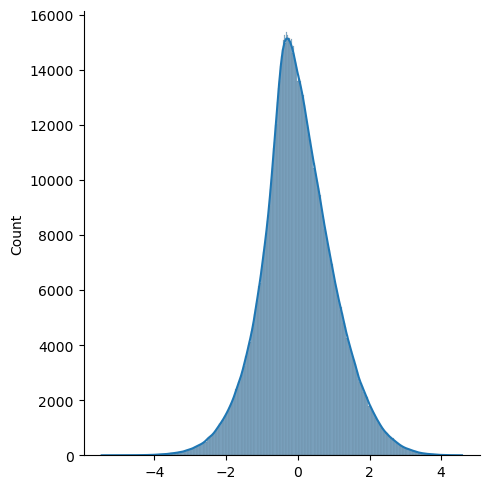

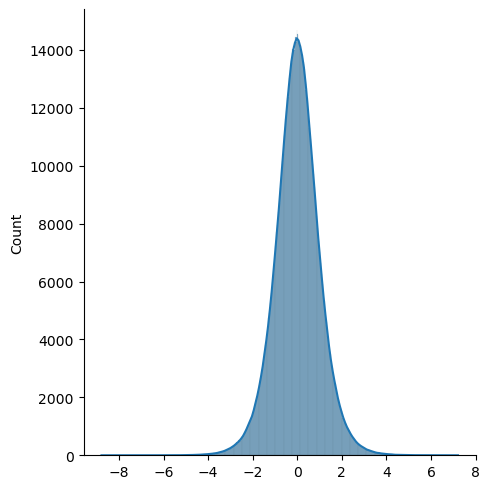

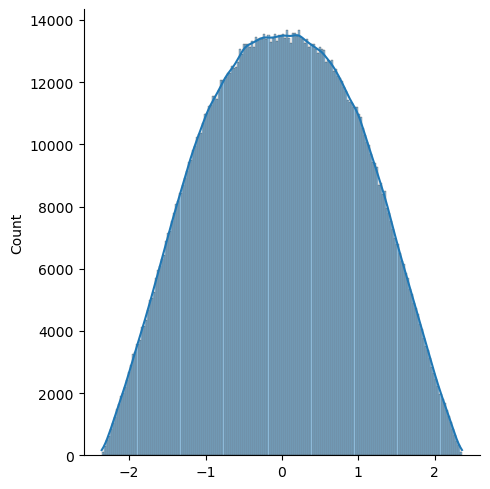

In [12]:
for i in range(dataset.X_data.whitened_data.shape[1]):

    sns.displot(np.array(dataset.X_data.whitened_data[:, i]), kde=True)
    plt.show()

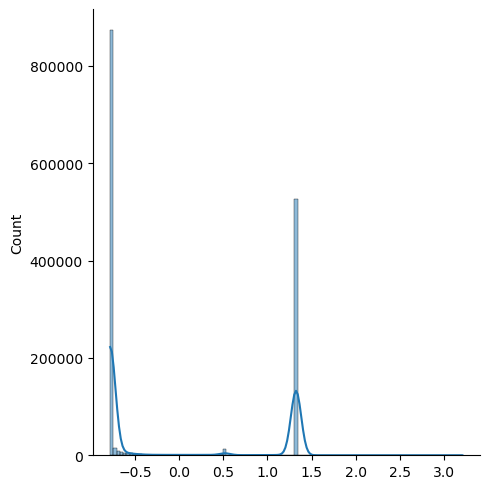

In [13]:
for i in range(dataset.y_data.whitened_data.shape[1]):

    sns.displot(np.array(dataset.y_data.whitened_data[:, i]), kde=True)
    plt.show()

### Build Flowjax MAF

In [15]:
key = jax.random.key(0)

train_dataset, val_dataset = dataset.split(key, train_frac=0.8)

flow_conditional = masked_autoregressive_flow(
    key=key,
    base_dist=Normal(jnp.zeros(train_dataset.X.shape[1])),  # X dimensionality
    cond_dim=train_dataset.y.shape[1],                       # Condition on y
    flow_layers=6,
    nn_width=96,
    nn_depth=3,
)

### Training Loop

In [ ]:
# Configuration
batch_size = 2048
n_epochs = 2000
learning_rate = 1e-3

# Create optimizer
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(eqx.filter(flow_conditional, eqx.is_array))

# Loss function for conditional flow
@eqx.filter_value_and_grad
def loss_fn(flow, x, condition):
    """Negative log-likelihood for conditional flow."""
    return -jnp.mean(flow.log_prob(x, condition=condition))

# Training step
@eqx.filter_jit
def train_step(flow, opt_state, x, condition):
    """Single training step with gradient update."""
    loss, grads = loss_fn(flow, x, condition)
    updates, opt_state = optimizer.update(grads, opt_state)
    flow = eqx.apply_updates(flow, updates)
    return flow, opt_state, loss

# Training loop
losses = []
N = len(train_dataset)

for epoch in tqdm(range(1, n_epochs + 1)):
    # Random permutation
    perm = np.random.permutation(N)
    x_perm = train_dataset.X[perm]
    y_perm = train_dataset.y[perm]
    
    batch_losses = []
    for i in range(0, N, batch_size):
        batch_x = x_perm[i:i+batch_size]
        batch_y = y_perm[i:i+batch_size]
        
        # Skip incomplete batches
        if batch_x.shape[0] < batch_size:
            continue
        
        flow, opt_state, loss = train_step(flow_conditional, opt_state, batch_x, batch_y)
        batch_losses.append(float(loss))
    
    losses.append(np.mean(batch_losses))
    
    # if epoch % 50 == 0:
    #     print(f"Epoch {epoch:4d} | NLL = {losses[-1]:.4f}")


  1%|          | 16/2000 [00:32<52:34,  1.59s/it] 

In [ ]:
sns.lineplot(x=np.arange(1, n_epochs + 1), y=losses)
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Training Loss over Epochs")
plt.show()


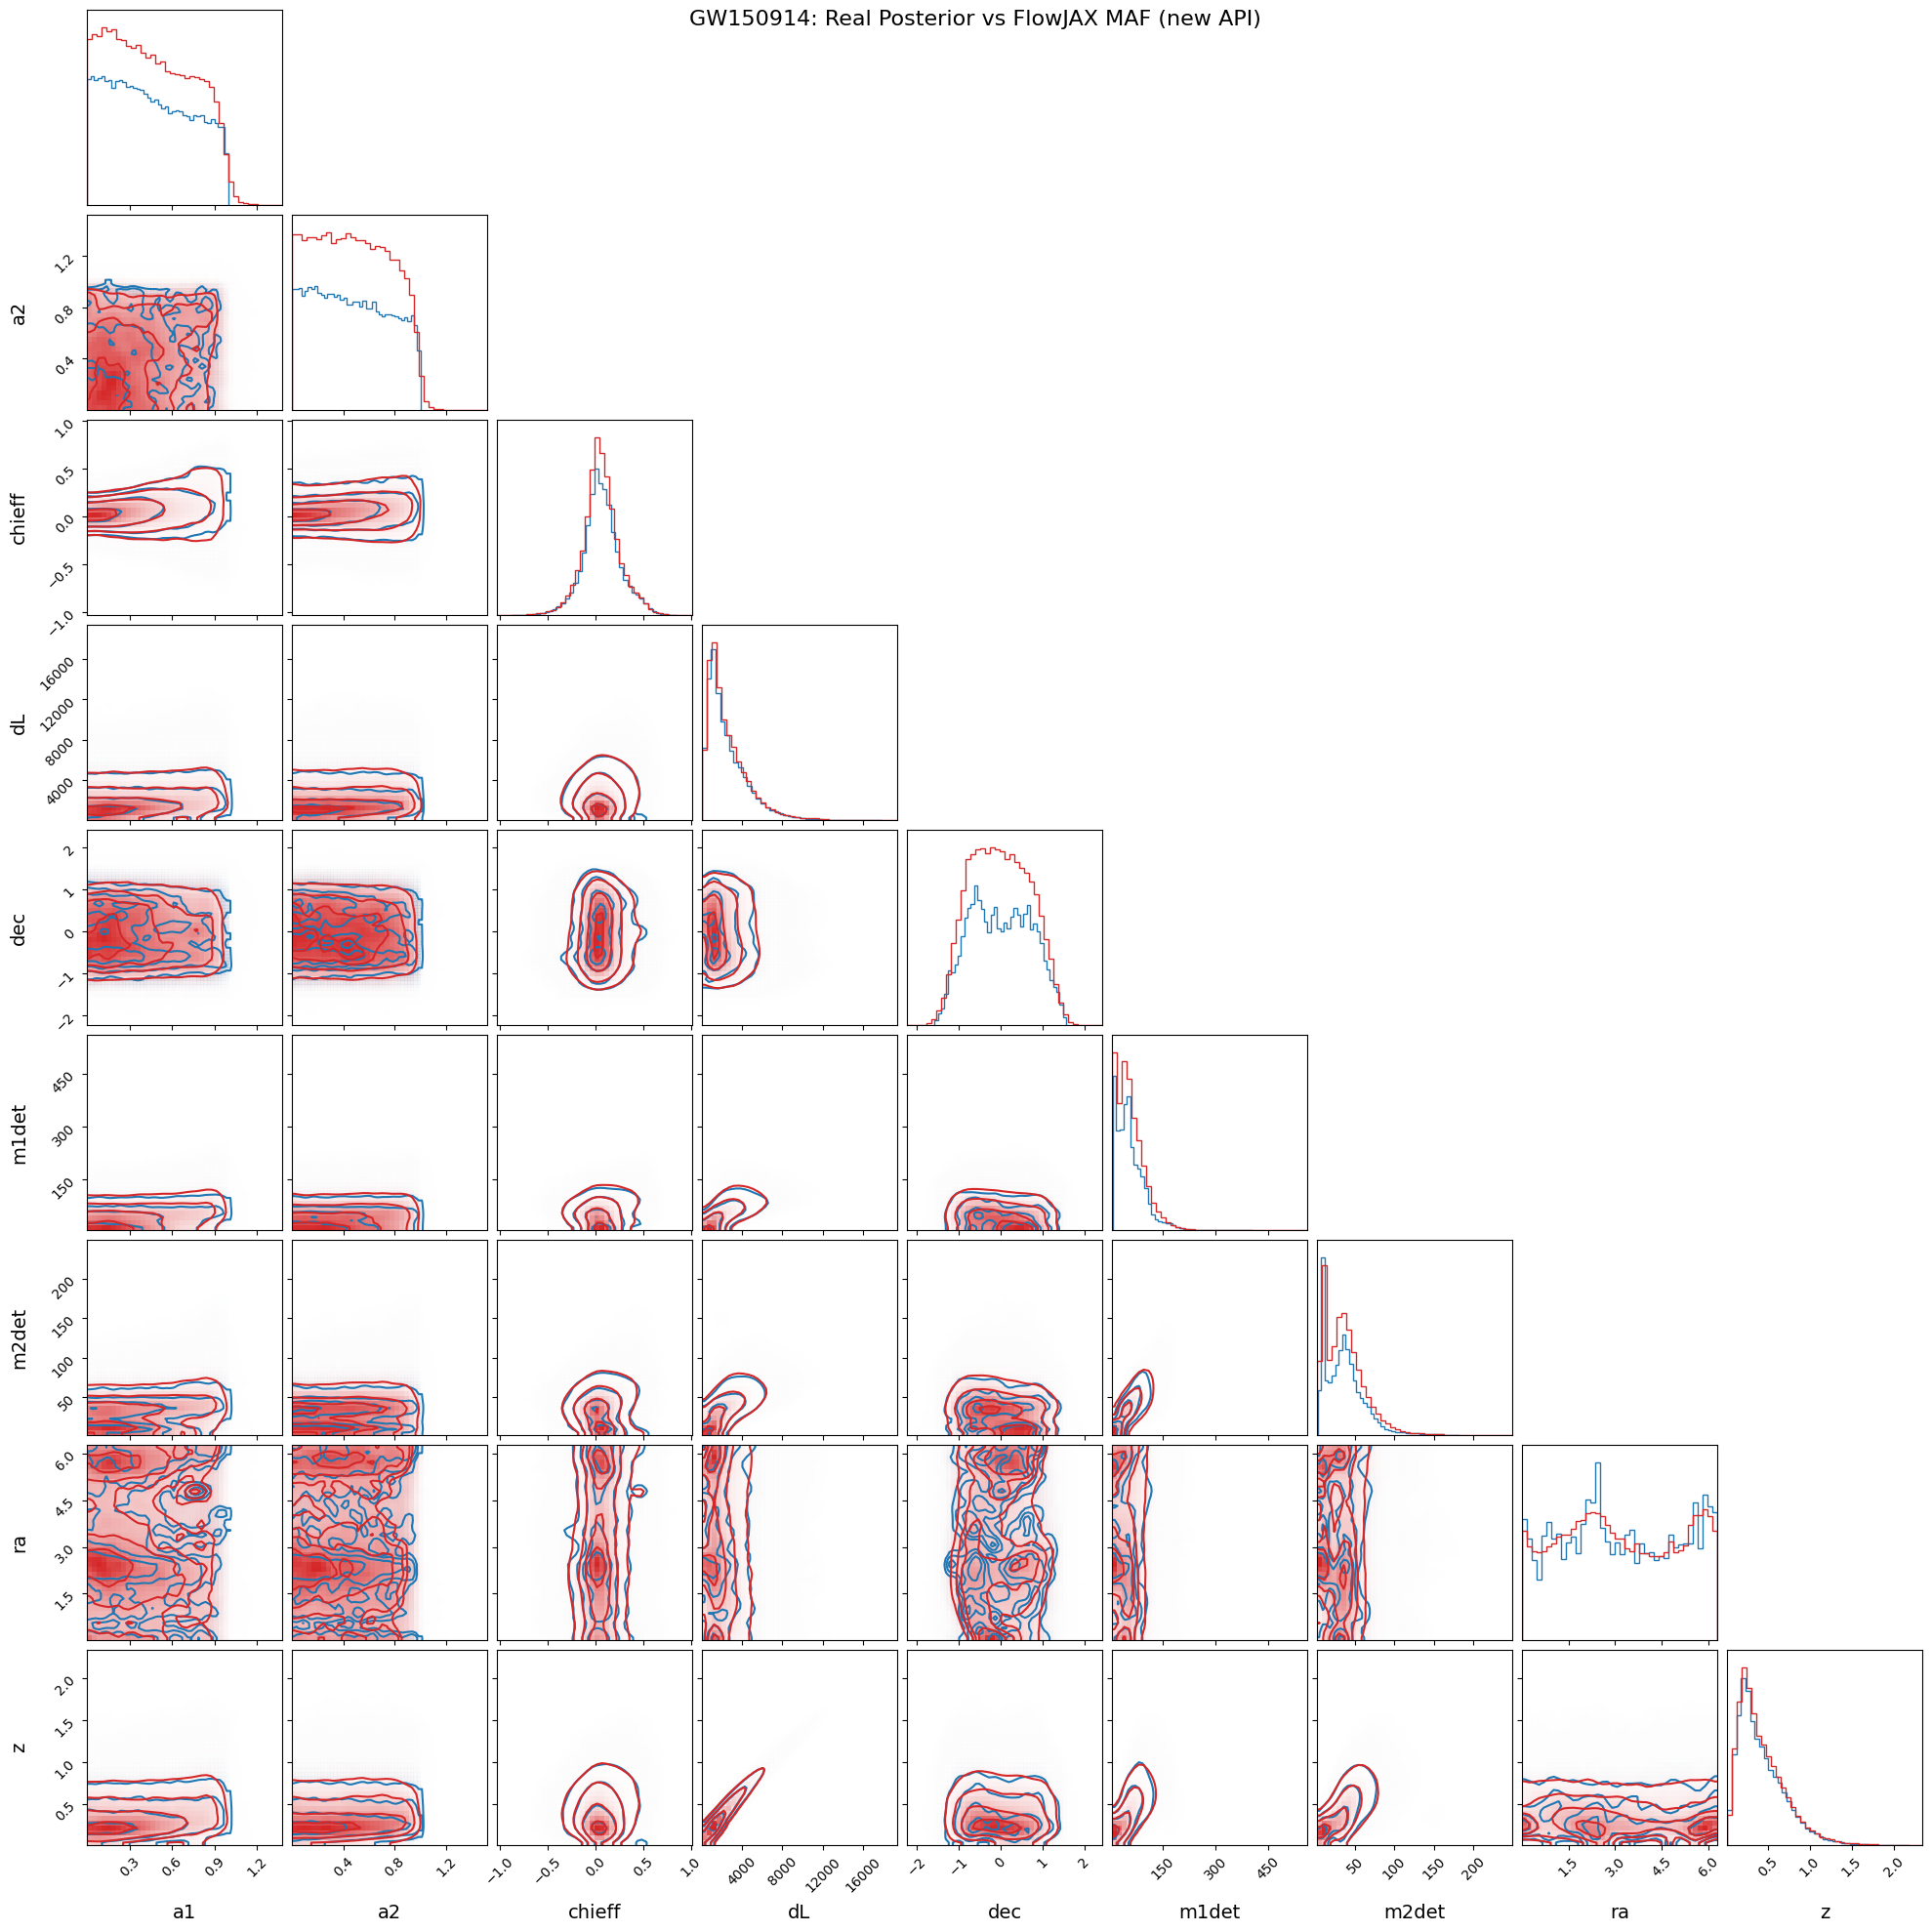

In [ ]:
# ============================================================
# 5. SAMPLING FROM THE FLOW
# ============================================================

key, subkey = jax.random.split(key)
z_samples = np.array(flow.sample(subkey, (N,)))

# ============================================================
# 6. INVERSE TRANSFORM BACK TO PHYSICAL SPACE
# ============================================================

x_rec = data.inverse_whiten_data(z_samples)

# ============================================================
# 7. DIAGNOSTIC CORNER PLOT
# ============================================================

labels = col_names# [r"$m_{1,\rm det}$", r"$m_{2,\rm det}$", r"$D_L$", r"$\chi_\mathrm{eff}$", r"$\alpha$", r"$\delta$"]
ranges = [(0, 1), (0, 1), (-1, 1), (0, 8000), (-1, 1),(0, 200), (0, 200), (0, 2*np.pi), (0, 2)]
fig = corner.corner(
    np.array(data.samples),
    labels=labels,
    color="C0",
    bins=40,
    plot_datapoints=False,
    smooth=1.0,
    label_kwargs={"fontsize": 14},
    # range = ranges,
)

corner.corner(
    np.array(x_rec),
    fig=fig,
    color="C3",
    bins=40,
    plot_datapoints=False,
    smooth=1.0,
    # range = ranges,
)

plt.suptitle(f"Real Posterior vs FlowJAX MAF for {N} BBH samples from GWTC-4", fontsize=16)
plt.show()


### Quantitative Evaluation: Summary Statistics

Let's compare the descriptive statistics (mean, standard deviation, and correlations) of the original samples and the flow-generated samples. A good fit should show similar statistics between the two sets.

In [ ]:
import pandas as pd

# Convert to pandas DataFrames for easy summary statistics
df_samples = pd.DataFrame(np.array(data.samples), columns=labels)
df_rec = pd.DataFrame(x_rec, columns=labels)

print("--- Original Samples Summary Statistics ---")
display(df_samples.describe())

print("\n--- Flow-Generated Samples Summary Statistics ---")
display(df_rec.describe())

print("\n--- Original Samples Correlation Matrix ---")
display(df_samples.corr())

print("\n--- Flow-Generated Samples Correlation Matrix ---")
display(df_rec.corr())

--- Original Samples Summary Statistics ---


,"$m_{1,\rm det}$","$m_{2,\rm det}$",$D_L$,$\chi_\mathrm{eff}$,$\alpha$,$\delta$
count,476406.000000,476406.000000,476406.000000,476406.000000,4.764060e+05,476406.000000
mean,81.196220,61.350121,3.606568,0.096861,3.137291e+00,0.000445
std,51.271690,40.788799,2.619539,0.190884,1.814671e+00,0.706593
min,1.010990,1.009583,0.008192,-0.928123,7.365814e-07,-1.569142
25%,47.214356,32.812764,1.673406,-0.018335,1.561486e+00,-0.561313
50%,72.483540,53.727011,2.982561,0.085088,3.137989e+00,-0.000479
75%,104.281940,80.710871,4.905326,0.213395,4.705215e+00,0.562742
max,1051.897827,660.433716,25.138866,0.943511,6.283173e+00,1.566937



--- Flow-Generated Samples Summary Statistics ---


,"$m_{1,\rm det}$","$m_{2,\rm det}$",$D_L$,$\chi_\mathrm{eff}$,$\alpha$,$\delta$
count,476406.000000,476406.000000,476406.000000,476406.000000,4.764060e+05,476406.000000
mean,81.390602,61.694916,3.614535,0.097590,3.148881e+00,-0.002287
std,52.094711,41.514183,2.598310,0.190902,1.809960e+00,0.703932
min,0.643652,0.015190,0.008901,-0.996964,6.663023e-16,-2.595817
25%,47.326469,32.987169,1.690958,-0.019433,1.584074e+00,-0.561534
50%,72.459251,53.888943,3.013245,0.086441,3.157661e+00,-0.003825
75%,104.362267,80.986673,4.917939,0.214338,4.707179e+00,0.555559
max,2168.829590,1857.272095,56.820114,0.979466,6.283185e+00,1.922836



--- Original Samples Correlation Matrix ---


,"$m_{1,\rm det}$","$m_{2,\rm det}$",$D_L$,$\chi_\mathrm{eff}$,$\alpha$,$\delta$
"$m_{1,\rm det}$",1.000000,0.898643,0.544620,0.068561,-0.001138,-0.000320
"$m_{2,\rm det}$",0.898643,1.000000,0.574899,0.052243,0.000208,-0.000524
$D_L$,0.544620,0.574899,1.000000,0.124642,-0.001620,-0.001538
$\chi_\mathrm{eff}$,0.068561,0.052243,0.124642,1.000000,0.000440,-0.000778
$\alpha$,-0.001138,0.000208,-0.001620,0.000440,1.000000,0.008268
$\delta$,-0.000320,-0.000524,-0.001538,-0.000778,0.008268,1.000000



--- Flow-Generated Samples Correlation Matrix ---


,"$m_{1,\rm det}$","$m_{2,\rm det}$",$D_L$,$\chi_\mathrm{eff}$,$\alpha$,$\delta$
"$m_{1,\rm det}$",1.000000,0.902651,0.533912,0.071291,0.004533,0.000225
"$m_{2,\rm det}$",0.902651,1.000000,0.564717,0.054347,0.005669,0.000037
$D_L$,0.533912,0.564717,1.000000,0.129347,0.006675,-0.004516
$\chi_\mathrm{eff}$,0.071291,0.054347,0.129347,1.000000,0.007547,-0.003095
$\alpha$,0.004533,0.005669,0.006675,0.007547,1.000000,0.011156
$\delta$,0.000225,0.000037,-0.004516,-0.003095,0.011156,1.000000


### Quantitative Evaluation: Kolmogorov-Smirnov (KS) Test

The Kolmogorov-Smirnov test is a non-parametric test that compares the empirical cumulative distribution functions (ECDFs) of two samples. We'll perform it for each 1D marginal distribution to check if the original and flow-generated samples come from the same underlying distribution. A small p-value (e.g., < 0.05) would suggest that the distributions are statistically significantly different.

In [ ]:
from scipy import stats

print("--- Kolmogorov-Smirnov Test for 1D Marginals ---")
print("H0: The two samples are drawn from the same continuous distribution.")
print("If p-value is small (e.g., < 0.05), we reject H0, meaning distributions are likely different.")

for i, label in enumerate(labels):
    stat, p_value = stats.kstest(np.array(data.samples[:, i]), x_rec[:, i])
    print(f"\nParameter: {label}")
    print(f"  KS Statistic: {stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  -> Distributions are statistically significantly different (reject H0)")
    else:
        print("  -> Distributions are not statistically significantly different (fail to reject H0)")

--- Kolmogorov-Smirnov Test for 1D Marginals ---
H0: The two samples are drawn from the same continuous distribution.
If p-value is small (e.g., < 0.05), we reject H0, meaning distributions are likely different.

Parameter: $m_{1,\rm det}$
  KS Statistic: 0.0015
  P-value: 0.6786
  -> Distributions are not statistically significantly different (fail to reject H0)

Parameter: $m_{2,\rm det}$
  KS Statistic: 0.0029
  P-value: 0.0404
  -> Distributions are statistically significantly different (reject H0)

Parameter: $D_L$
  KS Statistic: 0.0057
  P-value: 0.0000
  -> Distributions are statistically significantly different (reject H0)

Parameter: $\chi_\mathrm{eff}$
  KS Statistic: 0.0038
  P-value: 0.0024
  -> Distributions are statistically significantly different (reject H0)

Parameter: $\alpha$
  KS Statistic: 0.0043
  P-value: 0.0003
  -> Distributions are statistically significantly different (reject H0)

Parameter: $\delta$
  KS Statistic: 0.0048
  P-value: 0.0000
  -> Distribution